# Multi-Class Cancer Classification using RNA-Seq Gene Expression Data

## Objective

The objective of this project is to classify patients into one of five cancer types using RNA-Seq gene expression data. Along with building classification models, this project investigates the effect of Principal Component Analysis (PCA) on different machine learning algorithms and compares their performance.

## Problem Statement

Cancer diagnosis using gene expression data is an important application
of machine learning in healthcare.

This project aims to classify patients into one of five cancer types
using RNA-Seq gene expression values.

The objective is to compare multiple machine learning algorithms and
study the impact of PCA on classification performance.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


## Source

UCI Machine Learning Repository

## Dataset Summary

| Property | Value |
|-----------|-------|
| Samples | 801 |
| Features | 20,531 |
| Classes | 5 |
| Task | Multi-Class Classification |

### Cancer Types

- BRCA
- COAD
- KIRC
- LUAD
- PRAD

# Data Understanding

The dataset consists of two files:

- **data.csv** containing RNA-Seq gene expression values.
- **labels.csv** containing the corresponding cancer labels.

Before merging both datasets, the ordering of patient IDs was verified to ensure that every feature vector corresponded to the correct target label.

Since both datasets shared the same ordering, they were safely merged using the common patient identifier.


In [ ]:
data = pd.read_csv("data.csv")

In [ ]:
labels = pd.read_csv("labels.csv")

In [ ]:
data.sample(5)

,Unnamed: 0,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
331,sample_331,0.0,2.059113,2.506094,7.402500,10.958705,0.0,6.093165,0.356482,0.0,...,5.005041,8.712427,10.234291,8.594985,9.957193,12.400967,9.745041,10.490169,3.934960,0.0
674,sample_674,0.0,4.229896,4.028003,7.032894,9.754323,0.0,7.567378,0.612777,0.0,...,6.524023,9.406613,10.242114,6.635736,10.744834,10.559951,10.714941,10.237688,6.260805,0.0
653,sample_653,0.0,3.390503,2.948732,6.842614,8.720600,0.0,7.711054,0.623118,0.0,...,7.005613,9.252334,9.876443,3.717605,10.666455,11.343774,10.628309,9.585250,5.543836,0.0
58,sample_58,0.0,1.985792,3.640031,6.262604,9.141946,0.0,6.901567,0.000000,0.0,...,5.448108,7.876400,9.319575,4.670410,9.339271,11.640548,9.783150,8.948522,5.318035,0.0
531,sample_531,0.0,2.935215,3.494134,7.714294,9.933779,0.0,7.240305,0.597031,0.0,...,5.868237,9.021743,9.476789,2.488926,8.857667,12.202754,9.958519,8.907801,3.788226,0.0


In [ ]:
labels.sample(5)

,Unnamed: 0,Class
441,sample_441,BRCA
583,sample_583,KIRC
17,sample_17,KIRC
586,sample_586,LUAD
61,sample_61,KIRC


In [ ]:
print(data.shape)
print(labels.shape)

(801, 20532)
(801, 2)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Columns: 20532 entries, Unnamed: 0 to gene_20530
dtypes: float64(20531), object(1)
memory usage: 125.5+ MB


In [ ]:
labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  801 non-null    object
 1   Class       801 non-null    object
dtypes: object(2)
memory usage: 12.6+ KB


# Exploratory Data Analysis (EDA)

Before training any machine learning model, the quality of the dataset was evaluated.

The following checks were performed:

- Missing Values
- Duplicate Rows
- Duplicate Patient IDs
- Data Types
- Class Distribution

## Observations

- No missing values were found.
- No duplicate rows were present.
- Every patient ID was unique.
- The dataset contains 20,531 numerical gene expression features.
- The target variable contains five cancer classes.

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
labels.duplicated().sum()

np.int64(0)

In [ ]:
data.isnull().sum()

,0
Unnamed: 0,0
gene_0,0
gene_1,0
gene_2,0
gene_3,0
...,...
gene_20526,0
gene_20527,0
gene_20528,0
gene_20529,0


In [ ]:
labels.isnull().sum()

,0
Unnamed: 0,0
Class,0


In [ ]:
#check ordering manually

for i in range(data['Unnamed: 0'].shape[0]):
    if data['Unnamed: 0'][i] != labels['Unnamed: 0'][i]:
      print("no")
print("yes")


yes


In [ ]:
(data['Unnamed: 0'] == labels['Unnamed: 0']).all() # check ordering

np.True_

In [ ]:
df = pd.merge(data, labels, on="Unnamed: 0")

In [ ]:
df.sample(5)

,Unnamed: 0,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530,Class
37,sample_37,0.000000,4.416259,4.188978,6.664198,9.070819,0.0,7.915318,0.906275,0.0,...,8.302470,10.431884,2.168899,9.402496,12.072283,10.637458,9.379959,6.148450,0.906275,LUAD
236,sample_236,0.000000,2.262674,1.863859,6.838624,9.012979,0.0,7.300792,1.383884,0.0,...,8.638747,9.748228,1.383884,10.338324,11.864144,10.200396,9.388192,4.931229,0.000000,KIRC
192,sample_192,0.531868,3.755486,1.868963,6.726123,10.859449,0.0,7.610154,0.000000,0.0,...,8.129752,9.938672,6.847158,9.011046,11.632282,9.872284,9.073266,9.106317,0.000000,LUAD
143,sample_143,0.000000,1.904465,1.958434,6.072056,10.188811,0.0,6.968529,0.807932,0.0,...,8.397910,9.238818,2.883777,9.723050,12.740906,9.654154,8.905568,4.130519,0.000000,KIRC
14,sample_14,0.000000,1.964842,2.183010,6.596832,10.248141,0.0,7.087251,0.441483,0.0,...,10.829588,10.404567,6.588536,8.952596,10.461725,10.582857,9.488141,3.261967,0.000000,BRCA


In [ ]:
df.shape

(801, 20533)

In [ ]:
df.head()

,Unnamed: 0,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530,Class
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0,PRAD
1,sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0,LUAD
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0,PRAD
3,sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,...,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0,PRAD
4,sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,...,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0,BRCA


In [ ]:
print(df.shape)

df.info()

df.describe()

(801, 20533)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Columns: 20533 entries, Unnamed: 0 to Class
dtypes: float64(20531), object(2)
memory usage: 125.5+ MB


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
count,801.000000,801.000000,801.000000,801.000000,801.000000,801.0,801.000000,801.000000,801.000000,801.000000,...,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000
mean,0.026642,3.010909,3.095350,6.722305,9.813612,0.0,7.405509,0.499882,0.016744,0.013428,...,5.896573,8.765891,10.056252,4.847727,9.741987,11.742228,10.155271,9.590726,5.528177,0.095411
std,0.136850,1.200828,1.065601,0.638819,0.506537,0.0,1.108237,0.508799,0.133635,0.204722,...,0.746399,0.603176,0.379278,2.382728,0.533898,0.670371,0.580569,0.563849,2.073859,0.364529
min,0.000000,0.000000,0.000000,5.009284,8.435999,0.0,3.930747,0.000000,0.000000,0.000000,...,2.853517,6.678368,8.669456,0.000000,7.974942,9.045255,7.530141,7.864533,0.593975,0.000000
25%,0.000000,2.299039,2.390365,6.303346,9.464466,0.0,6.676042,0.000000,0.000000,0.000000,...,5.454926,8.383834,9.826027,3.130750,9.400747,11.315857,9.836525,9.244219,4.092385,0.000000
50%,0.000000,3.143687,3.127006,6.655893,9.791599,0.0,7.450114,0.443076,0.000000,0.000000,...,5.972582,8.784144,10.066385,5.444935,9.784524,11.749802,10.191207,9.566511,5.218618,0.000000
75%,0.000000,3.883484,3.802534,7.038447,10.142324,0.0,8.121984,0.789354,0.000000,0.000000,...,6.411292,9.147136,10.299025,6.637412,10.082269,12.177852,10.578561,9.917888,6.876382,0.000000
max,1.482332,6.237034,6.063484,10.129528,11.355621,0.0,10.718190,2.779008,1.785592,4.067604,...,7.771054,11.105431,11.318243,9.207495,11.811632,13.715361,11.675653,12.813320,11.205836,5.254133


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Unnamed: 0'].duplicated().sum()

np.int64(0)

# Class Distribution

The dataset exhibits moderate class imbalance.

BRCA contains the highest number of samples, while COAD contains the fewest.

Since the classes are not perfectly balanced, metrics such as **Precision**, **Recall**, and **F1-Score** provide a more reliable evaluation than Accuracy alone.


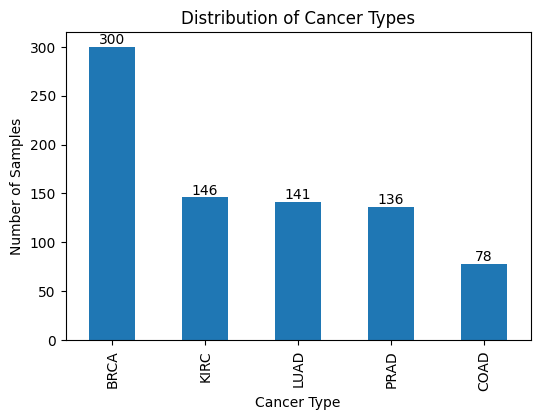

In [ ]:
import matplotlib.pyplot as plt

ax = df['Class'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Distribution of Cancer Types")
plt.xlabel("Cancer Type")
plt.ylabel("Number of Samples")

for container in ax.containers:
    ax.bar_label(container)

plt.show()


In [ ]:
df.head()

,Unnamed: 0,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530,Class
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0,PRAD
1,sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0,LUAD
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0,PRAD
3,sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,...,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0,PRAD
4,sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,...,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0,BRCA


# Data Preprocessing

## Step 1 — Removing Patient ID

The patient identifier was removed because it serves only as a unique identifier and carries no predictive information about the cancer type.


## Step 2 — Separating Features and Target

The dataset was divided into

- $X$ → Gene Expression Features
- $y$ → Cancer Labels

In [ ]:
X = df.drop(columns=['Unnamed: 0', 'Class'])
y = df['Class']

In [ ]:
X

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.000000
1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.000000
2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.000000
3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.000000
4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,0.0,1.865642,2.718197,7.350099,10.006003,0.0,6.764792,0.496922,0.0,0.0,...,6.088133,9.118313,10.004852,4.484415,9.614701,12.031267,9.813063,10.092770,8.819269,0.000000
797,0.0,3.942955,4.453807,6.346597,10.056868,0.0,7.320331,0.000000,0.0,0.0,...,6.371876,9.623335,9.823921,6.555327,9.064002,11.633422,10.317266,8.745983,9.659081,0.000000
798,0.0,3.249582,3.707492,8.185901,9.504082,0.0,7.536589,1.811101,0.0,0.0,...,5.719386,8.610704,10.485517,3.589763,9.350636,12.180944,10.681194,9.466711,4.677458,0.586693
799,0.0,2.590339,2.787976,7.318624,9.987136,0.0,9.213464,0.000000,0.0,0.0,...,5.785237,8.605387,11.004677,4.745888,9.626383,11.198279,10.335513,10.400581,5.718751,0.000000


In [ ]:
y

,Class
0,PRAD
1,LUAD
2,PRAD
3,PRAD
4,BRCA
...,...
796,BRCA
797,LUAD
798,COAD
799,PRAD


## Step 3 — Label Encoding

The target labels were converted into numerical form using **LabelEncoder**.

Generated Mapping:

- BRCA $\rightarrow$ 0
- COAD $\rightarrow$ 1
- KIRC $\rightarrow$ 2
- LUAD $\rightarrow$ 3
- PRAD $\rightarrow$ 4

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

In [ ]:
le.classes_

array(['BRCA', 'COAD', 'KIRC', 'LUAD', 'PRAD'], dtype=object)

## Step 4 — Train-Test Split

The dataset was divided into training and testing subsets using an 80-20 split.

A **Stratified Split** was performed to preserve the original class distribution in both subsets.

This ensures a representative evaluation of the trained models.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((640, 20531), (161, 20531), (640,), (161,))

# Experiment 1 — Standardization

The gene expression values were standardized using **StandardScaler**.

The scaler was fitted only on the training data and then applied to the testing data.

This prevents **data leakage**.

### Why Standardization?

Principal Component Analysis is a **variance-based algorithm**.

Without scaling, features with larger numerical ranges dominate the computation of principal components.

Standardization transforms each feature as

$$
z=\frac{x-\mu}{\sigma}
$$

where

- $\mu$ = Mean
- $\sigma$ = Standard Deviation

This ensures that every feature contributes equally during PCA.

In [ ]:
scaler = StandardScaler()

In [ ]:
scaler.fit(X_train)

StandardScaler()

In [ ]:
scaler.mean_

array([0.02911648, 3.00646795, 3.10061096, ..., 9.59577865, 5.50126506,
       0.0962166 ])

In [ ]:
scaler.var_

array([0.02097431, 1.43364136, 1.23680363, ..., 0.32054273, 4.24620304,
       0.14715862])

In [ ]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled.shape

(640, 20531)

# Experiment 2 — Principal Component Analysis (PCA)

The original dataset contains

$$
20,531
$$

gene expression features.

Such a high-dimensional dataset is computationally expensive and susceptible to the **Curse of Dimensionality**.

PCA was applied to reduce dimensionality while preserving the majority of the variance present in the data.

Initially,

```python
PCA(n_components=0.95)
```

was used.

This reduced the feature space from

$$
20531 \rightarrow 434
$$

Principal Components while preserving **95%** of the total variance.

It is important to note that PCA **does not select the best genes**.

Instead, it creates entirely new features called **Principal Components**, where each principal component is a linear combination of the original gene expression values.


In [ ]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

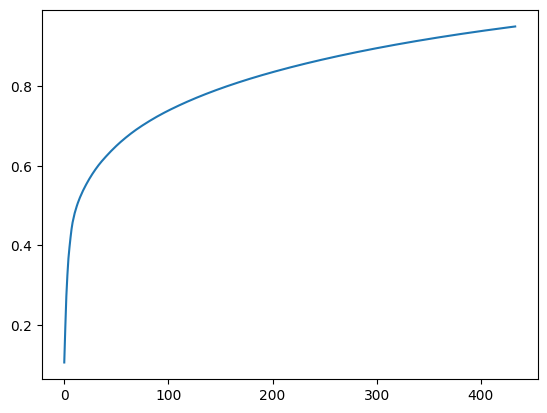

In [ ]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

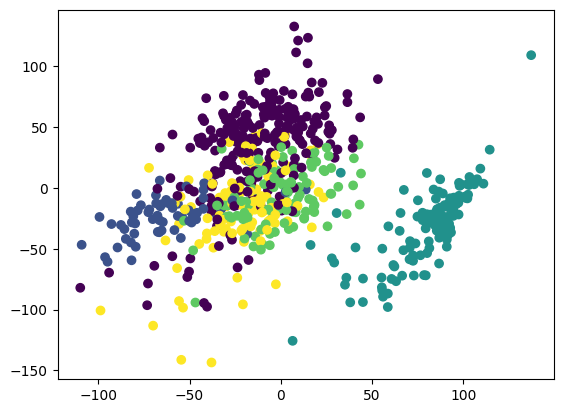

In [ ]:
plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=y_train
)

In [ ]:
X_train_pca.shape, X_test_pca.shape

((640, 434), (161, 434))

In [ ]:
X_train_scaled.shape

(640, 20531)

# Baseline Model Comparison (With PCA)

Several machine learning algorithms were trained using the PCA-transformed dataset.

| Model | Accuracy |
|--------|---------:|
| Logistic Regression | **100%** |
| SVM | 98% |
| KNN | 97% |
| Decision Tree | 90% |
| Random Forest | 89% |
| Gaussian Naive Bayes | 44% |


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr.fit(X_train_pca, y_train)

LogisticRegression(max_iter=5000, random_state=42)

In [ ]:
y_pred = lr.predict(X_test_pca)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 1.0
              precision    recall  f1-score   support

        BRCA       1.00      1.00      1.00        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      1.00      1.00        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train_pca, y_train)

y_pred = knn.predict(X_test_pca)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9751552795031055
              precision    recall  f1-score   support

        BRCA       0.97      0.98      0.98        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      0.97      0.98        30
        LUAD       1.00      0.93      0.96        28
        PRAD       0.93      1.00      0.96        27

    accuracy                           0.98       161
   macro avg       0.98      0.98      0.98       161
weighted avg       0.98      0.98      0.98       161



In [ ]:
from sklearn.svm import SVC

svm = SVC(random_state=42)

svm.fit(X_train_pca, y_train)

y_pred = svm.predict(X_test_pca)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9813664596273292
              precision    recall  f1-score   support

        BRCA       0.97      1.00      0.98        60
        COAD       1.00      0.94      0.97        16
        KIRC       1.00      1.00      1.00        30
        LUAD       0.96      0.93      0.95        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.98       161
   macro avg       0.99      0.97      0.98       161
weighted avg       0.98      0.98      0.98       161



In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train_pca, y_train)

y_pred = nb.predict(X_test_pca)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.4409937888198758
              precision    recall  f1-score   support

        BRCA       0.70      0.12      0.20        60
        COAD       1.00      0.50      0.67        16
        KIRC       0.33      0.97      0.49        30
        LUAD       0.00      0.00      0.00        28
        PRAD       0.50      1.00      0.67        27

    accuracy                           0.44       161
   macro avg       0.51      0.52      0.40       161
weighted avg       0.50      0.44      0.34       161



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_pca, y_train)

y_pred = dt.predict(X_test_pca)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.906832298136646
              precision    recall  f1-score   support

        BRCA       0.85      0.97      0.91        60
        COAD       0.94      0.94      0.94        16
        KIRC       0.96      0.90      0.93        30
        LUAD       0.87      0.71      0.78        28
        PRAD       1.00      0.96      0.98        27

    accuracy                           0.91       161
   macro avg       0.92      0.90      0.91       161
weighted avg       0.91      0.91      0.91       161



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize Model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train
rf.fit(X_train_pca, y_train)

# Predict
y_pred = rf.predict(X_test_pca)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.8944099378881988
              precision    recall  f1-score   support

        BRCA       0.82      1.00      0.90        60
        COAD       1.00      0.75      0.86        16
        KIRC       1.00      0.97      0.98        30
        LUAD       0.95      0.64      0.77        28
        PRAD       0.89      0.93      0.91        27

    accuracy                           0.89       161
   macro avg       0.93      0.86      0.88       161
weighted avg       0.91      0.89      0.89       161



# Experiment 3 — Model Comparison Without PCA

Every model was retrained using the original feature space without applying PCA.

| Model | Accuracy |
|--------|---------:|
| Logistic Regression | 98% |
| SVM | 98% |
| KNN | 97% |
| Decision Tree | 95% |
| Random Forest | **98%** |
| Gaussian Naive Bayes | 57% |

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((640, 20531), (161, 20531), (640,), (161,))

In [ ]:
scaler = StandardScaler()

In [ ]:
scaler.fit(X_train)


StandardScaler()

In [ ]:
scaler.mean_

array([0.02911648, 3.00646795, 3.10061096, ..., 9.59577865, 5.50126506,
       0.0962166 ])

In [ ]:
scaler.var_

array([0.02097431, 1.43364136, 1.23680363, ..., 0.32054273, 4.24620304,
       0.14715862])

In [ ]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000, random_state=42)

In [ ]:
y_pred = lr.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9813664596273292
              precision    recall  f1-score   support

        BRCA       0.98      1.00      0.99        60
        COAD       0.94      0.94      0.94        16
        KIRC       1.00      1.00      1.00        30
        LUAD       0.96      0.93      0.95        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.98       161
   macro avg       0.98      0.97      0.97       161
weighted avg       0.98      0.98      0.98       161



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9751552795031055
              precision    recall  f1-score   support

        BRCA       0.97      0.98      0.98        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      0.97      0.98        30
        LUAD       1.00      0.93      0.96        28
        PRAD       0.93      1.00      0.96        27

    accuracy                           0.98       161
   macro avg       0.98      0.98      0.98       161
weighted avg       0.98      0.98      0.98       161



In [ ]:
from sklearn.svm import SVC

svm = SVC(random_state=42)

svm.fit(X_train_scaled, y_train)

y_pred = svm.predict(X_test_scaled)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9813664596273292
              precision    recall  f1-score   support

        BRCA       0.95      1.00      0.98        60
        COAD       1.00      0.94      0.97        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.93      0.96        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.98       161
   macro avg       0.99      0.97      0.98       161
weighted avg       0.98      0.98      0.98       161



In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

y_pred = nb.predict(X_test_scaled)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.5714285714285714
              precision    recall  f1-score   support

        BRCA       0.67      0.72      0.69        60
        COAD       1.00      0.06      0.12        16
        KIRC       0.42      0.73      0.54        30
        LUAD       0.54      0.46      0.50        28
        PRAD       0.65      0.48      0.55        27

    accuracy                           0.57       161
   macro avg       0.66      0.49      0.48       161
weighted avg       0.63      0.57      0.55       161



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_scaled, y_train)

y_pred = dt.predict(X_test_scaled)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9565217391304348
              precision    recall  f1-score   support

        BRCA       0.95      0.98      0.97        60
        COAD       1.00      0.88      0.93        16
        KIRC       0.97      1.00      0.98        30
        LUAD       0.93      0.89      0.91        28
        PRAD       0.96      0.96      0.96        27

    accuracy                           0.96       161
   macro avg       0.96      0.94      0.95       161
weighted avg       0.96      0.96      0.96       161



In [ ]:
# Initialize Model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train
rf.fit(X_train_scaled, y_train)

# Predict
y_pred = rf.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9875776397515528
              precision    recall  f1-score   support

        BRCA       0.97      1.00      0.98        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.93      0.96        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       0.99      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161



# Experiment 5 — PCA Variance Study

Rather than manually selecting the number of principal components, the amount of retained variance was allowed to determine the dimensionality.

Two experiments were conducted:

- PCA retaining **95%** variance
- PCA retaining **90%** variance

Both configurations achieved identical classification performance for Logistic Regression.

Therefore, preserving **90%** variance provides a more computationally efficient representation while maintaining predictive performance.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((640, 20531), (161, 20531), (640,), (161,))

In [ ]:
scaler = StandardScaler()

In [ ]:
scaler.fit(X_train)

StandardScaler()

In [ ]:
scaler.mean_

array([0.02911648, 3.00646795, 3.10061096, ..., 9.59577865, 5.50126506,
       0.0962166 ])

In [ ]:
pca = PCA(n_components=0.90)

X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

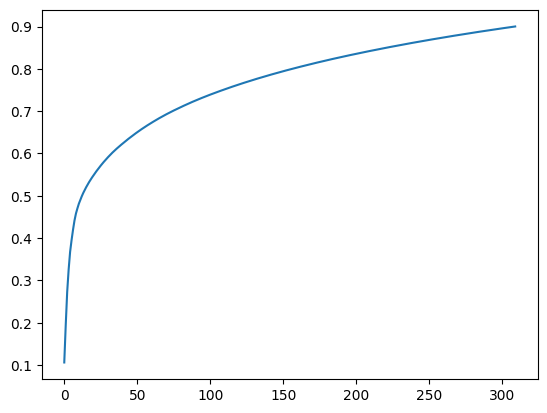

In [ ]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

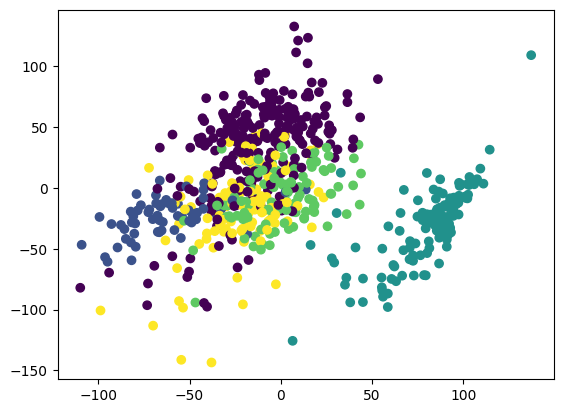

In [ ]:
plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=y_train
)

In [ ]:
X_train_pca.shape, X_test_pca.shape

((640, 310), (161, 310))

# Model Comparison With PCA retaining **90%** variance

Every model was retrained using the original feature space without applying PCA.

| Model | Accuracy |
|--------|---------:|
| Logistic Regression | 100% |
| SVM | 98% |
| KNN | 97% |
| Decision Tree | 89% |
| Random Forest | **98%** |
| Gaussian Naive Bayes | 52% |

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr.fit(X_train_pca, y_train)

LogisticRegression(max_iter=5000, random_state=42)

In [ ]:
y_pred = lr.predict(X_test_pca)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 1.0
              precision    recall  f1-score   support

        BRCA       1.00      1.00      1.00        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      1.00      1.00        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train_pca, y_train)

y_pred = knn.predict(X_test_pca)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9751552795031055
              precision    recall  f1-score   support

        BRCA       0.97      0.98      0.98        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      0.97      0.98        30
        LUAD       1.00      0.93      0.96        28
        PRAD       0.93      1.00      0.96        27

    accuracy                           0.98       161
   macro avg       0.98      0.98      0.98       161
weighted avg       0.98      0.98      0.98       161



In [ ]:
from sklearn.svm import SVC

svm = SVC(random_state=42)

svm.fit(X_train_pca, y_train)

y_pred = svm.predict(X_test_pca)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9813664596273292
              precision    recall  f1-score   support

        BRCA       0.97      1.00      0.98        60
        COAD       1.00      0.94      0.97        16
        KIRC       1.00      1.00      1.00        30
        LUAD       0.96      0.93      0.95        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.98       161
   macro avg       0.99      0.97      0.98       161
weighted avg       0.98      0.98      0.98       161



In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train_pca, y_train)

y_pred = nb.predict(X_test_pca)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.5279503105590062
              precision    recall  f1-score   support

        BRCA       0.77      0.17      0.27        60
        COAD       0.94      0.94      0.94        16
        KIRC       0.40      0.97      0.56        30
        LUAD       0.80      0.14      0.24        28
        PRAD       0.50      1.00      0.67        27

    accuracy                           0.53       161
   macro avg       0.68      0.64      0.54       161
weighted avg       0.68      0.53      0.45       161



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_pca, y_train)

y_pred = dt.predict(X_test_pca)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.8944099378881988
              precision    recall  f1-score   support

        BRCA       0.85      0.93      0.89        60
        COAD       0.88      0.94      0.91        16
        KIRC       0.96      0.87      0.91        30
        LUAD       0.91      0.75      0.82        28
        PRAD       0.93      0.96      0.95        27

    accuracy                           0.89       161
   macro avg       0.91      0.89      0.90       161
weighted avg       0.90      0.89      0.89       161



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize Model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train
rf.fit(X_train_pca, y_train)

# Predict
y_pred = rf.predict(X_test_pca)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9254658385093167
              precision    recall  f1-score   support

        BRCA       0.85      1.00      0.92        60
        COAD       1.00      0.81      0.90        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.71      0.83        28
        PRAD       0.96      0.96      0.96        27

    accuracy                           0.93       161
   macro avg       0.96      0.90      0.92       161
weighted avg       0.94      0.93      0.92       161



# Experimental Observations

## Observation 1

Applying PCA improved the performance of Logistic Regression.

Accuracy increased from

$$
98\% \rightarrow 100\%
$$

indicating that PCA successfully removed redundant information and produced a feature space that was easier for a linear classifier to separate.

---

## Observation 2

SVM and KNN exhibited minimal performance differences with and without PCA.

This suggests that these algorithms were already capable of handling the high-dimensional feature space effectively.

---

## Observation 3

Tree-based algorithms behaved differently.

Decision Trees and Random Forest achieved higher performance using the original feature space.

This is expected because tree-based algorithms naturally split on original feature values.

PCA transforms the original genes into linear combinations, reducing the interpretability and effectiveness of these splits.

---

## Observation 4

Gaussian Naive Bayes produced the lowest classification performance.

Its assumptions of conditional independence and Gaussian feature distributions appear to be unsuitable for this dataset.

---

## Observation 5

Retaining **90%** explained variance produced the same predictive performance as retaining **95%** variance.

Thus, preserving additional variance increased computational complexity without improving model accuracy.

---

# Final Conclusions

This study demonstrates that the effectiveness of preprocessing techniques depends strongly on the learning algorithm.

### Key Findings

- PCA significantly improved Logistic Regression.
- PCA had minimal impact on SVM and KNN.
- PCA reduced the performance of Decision Trees and Random Forest.
- Random Forest achieved nearly perfect performance using the original gene expression features.
- Preserving **90%** explained variance produced identical predictive performance while requiring fewer principal components.

These findings highlight that there is **no universal preprocessing pipeline**.

Instead, preprocessing should be selected according to both the learning algorithm and the characteristics of the underlying data.
